# Handwritten Digit Recognition
This notebook implements a clean, minimal, and reproducible machine learning pipeline to recognize handwritten digits. It uses the MNIST dataset (with a fallback to the smaller Digits dataset if needed) and trains a RandomForest classifier to achieve high performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml, load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Data Loading
We attempt to load the MNIST dataset (`mnist_784`) from OpenML. If loading fails or takes too long, we gracefully fall back to the smaller `load_digits` dataset.

In [2]:
# Try loading MNIST; fallback to sklearn digits dataset if failure occurs
try:
    print("Attempting to fetch MNIST dataset (this may take a minute)... ")
    start_time = time.time()
    # Using parser='auto' for compatibility and speed
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)
    print(f"Successfully loaded MNIST dataset with shape: {X.shape}. Time taken: {time.time() - start_time:.2f}s")
except Exception as e:
    print(f"Warning: Failed to fetch MNIST from OpenML ({e}). Falling back to load_digits...")
    digits = load_digits()
    X, y = digits.data, digits.target
    print(f"Successfully loaded fallback Digits dataset with shape: {X.shape}")

Attempting to fetch MNIST dataset (this may take a minute)... 


Successfully loaded MNIST dataset with shape: (70000, 784). Time taken: 43.11s


## 2. Data Preprocessing
To prepare the data for our machine learning model, we:
1. Normalize the pixel values to the range [0, 1] by dividing by the maximum pixel value.
2. Split the dataset into training (80%) and testing (20%) sets using a fixed random state (`random_state=42`) for reproducibility.

In [3]:
# Normalize pixel values to range [0, 1]
max_pixel_val = X.max()
if max_pixel_val > 0:
    X_normalized = X / max_pixel_val
else:
    X_normalized = X

# Perform 80/20 train/test split with reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (56000, 784)
Testing set shape: (14000, 784)


## 3. Model Implementation & Training
We implement a lightweight and robust `RandomForestClassifier` with a fixed random seed for reproducibility.

In [4]:
# Initialize the RandomForest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training the classifier model...")
start_train = time.time()
model.fit(X_train, y_train)
print(f"Model trained successfully in {time.time() - start_train:.2f}s.")

Training the classifier model...


Model trained successfully in 20.82s.


## 4. Evaluation & Metrics
We evaluate the model on the test set and display the overall accuracy, detailed classification metrics (precision, recall, f1-score), and a confusion matrix heatmap.

In [5]:
# Predict labels for test set
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%\n")

# Display classification metrics report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Overall Test Accuracy: 96.72%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.94      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



### Confusion Matrix
The confusion matrix helps us visualize which digits are most frequently misclassified.

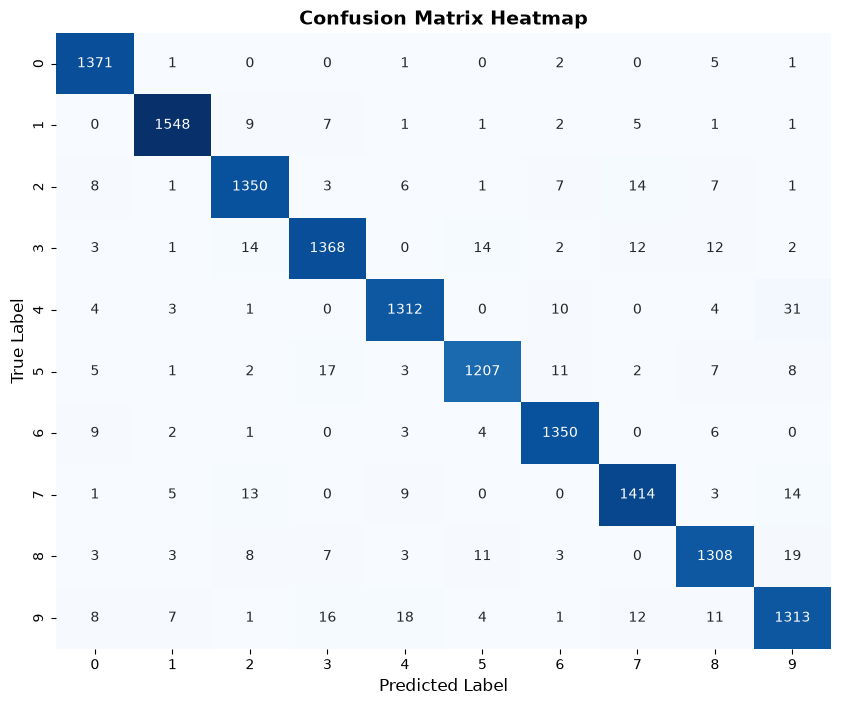

In [6]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

## 5. Visualizing Sample Predictions
Below are 5 sample images from the test set along with their true and predicted labels.

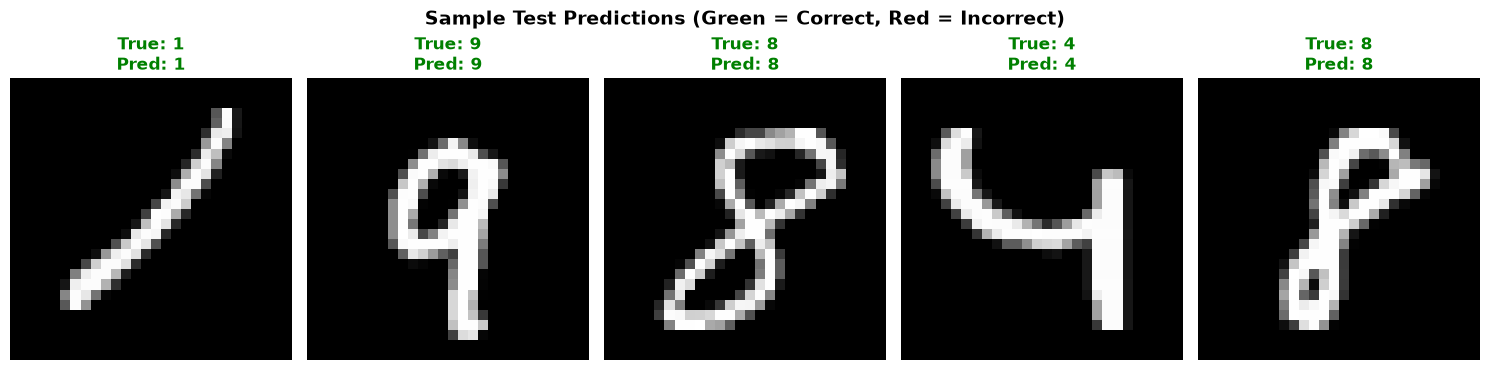

In [7]:
# Identify dimension of the image dynamically depending on dataset
img_side = int(np.sqrt(X.shape[1]))

# Select 5 random index positions from test set
indices = np.random.default_rng(seed=42).choice(len(X_test), size=5, replace=False)

# Plot sample predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, idx in enumerate(indices):
    img = X_test[idx].reshape(img_side, img_side)
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=12, fontweight='bold')

plt.suptitle("Sample Test Predictions (Green = Correct, Red = Incorrect)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()